# REVISE
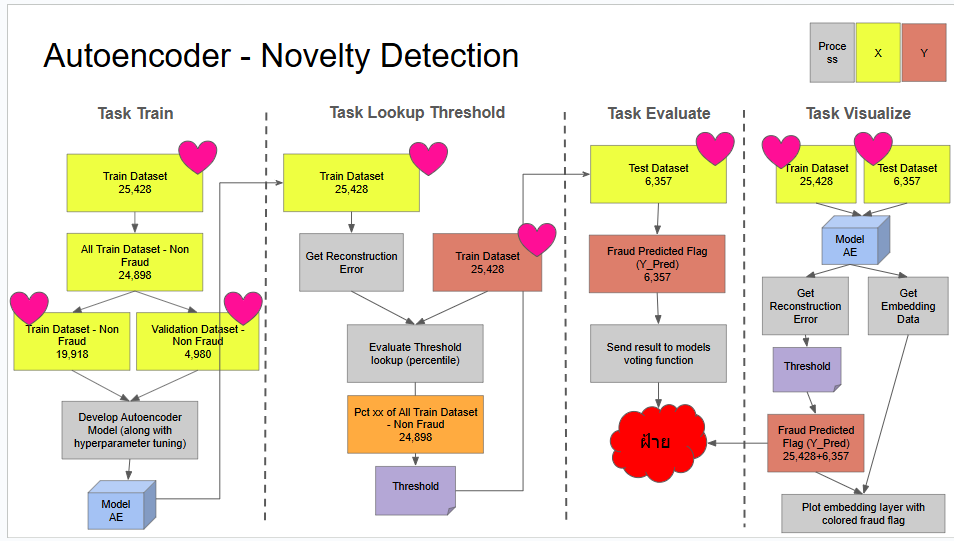

# [to do] add date_col , revise pipeline , add save result

# [done 21082025] plotly 3d , 2d(tsne shrink), select loss fn, pipeline (main)

## [future work] : VAE, อธิบายการนำเสนอ , เก็บ checkpoint แล้ว แต่ตอนนี้ยังไม่ได้เก็บ hyperparameter ในแต่ละครั้งที่จูน

# Read Library

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# !pip install tqdm

In [3]:
# !pip install torchview

In [4]:
# !pip install torchinfo

In [5]:
# !pip install boto3

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import math
from scipy import stats
import warnings
import re
import datetime
from package.utils import profile_data ,DotDict, timer, get_config, load_data, merge_data 

In [7]:
from package.model_deep_ae_20250829 import (set_seed,
                                generate_mock_data,
                                expand_rule_columns,
                                subset_by_timeunit,
                                split_train_test,
                                prepare_train_val_test_data,
                                Autoencoder,
                                # train_autoencoder,
                                save_checkpoint,
                                load_checkpoint     ,
                                train_autoencoder_checkpoint     ,
                                load_pickled_autoencoder     ,
                                plot_learning_curve,
                                get_reconstruction_error,
                                # plot_threshold_vs_metric_percentile,
                                flag_anomalies,
                                # detect_anomalies,
                                # tune_autoencoder_grid,
                                extract_embeddings,
                                plot_latent_space_2d,
                                plot_latent_space_3d,
                                create_pack_results,
                                # append_experiment_results,
                                )

from package.model_deep_ae_20250829 import (evaluate_fraud_predictions,
                                evaluate_thresholds,
                                run_training_pipeline,
                                run_threshold_and_plot_pipeline
                                )

# Read Data

In [8]:
mock1 = generate_mock_data(n_sales=10000, n_rules=10, fraud_ratio=0.05, seed=42)
mock1

function: generate_mock_data is starting...
function: generate_mock_data successfully executed at 1.811277151107788s


,sales_id,expected_dt,timeunit,flag_fraud,rule_1,rule_2,rule_3,rule_4,rule_5,rule_6,rule_7,rule_8,rule_9,rule_10
0,0,2024-12-30,l3,0,0.360016,-0.228151,0.282450,-0.724385,-0.585063,1.173842,-1.051548,-0.977754,-0.051581,-0.771890
1,1,2024-07-14,l3,1,2.272585,-0.017009,5.743308,2.880759,5.058952,4.337591,-0.622909,3.658322,2.477348,1.960721
2,2,2025-05-26,l3,0,1.024774,0.908937,-0.997060,-1.057251,-0.411173,-0.026746,-0.657898,1.040642,0.347390,0.406085
3,3,2025-05-25,l3,0,-1.266539,1.167291,-2.820169,0.834055,0.934312,-0.432401,1.272910,-0.063098,0.062432,0.339529
4,4,2025-06-17,l3,0,3.186575,1.344434,0.701131,-0.912804,0.143590,-0.813124,0.822111,0.140467,-1.124522,0.081125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9995,2024-07-01,l36,0,-1.393785,1.119496,-2.225198,0.355354,-1.114918,-0.348127,0.696269,-1.856022,-0.773980,-1.019967
59996,9996,2025-05-03,l36,0,1.914040,-0.250864,-0.670143,0.249901,-0.351280,-0.121383,0.274123,-0.559135,-0.084692,0.955931
59997,9997,2024-10-22,l36,0,0.580123,-0.555800,0.536215,-0.590000,-1.563657,0.052191,0.271158,-0.696574,-1.674949,-1.058655
59998,9998,2024-11-24,l36,0,1.381821,-0.886731,-0.431143,0.390082,0.668774,-1.953408,-0.687125,-1.467512,-0.240759,0.654136


# Autoencoder

- Autoencoder คือ neural network ที่เรียนรู้จะ compress ข้อมูล (encode) แล้ว reconstruct ข้อมูลเดิม (decode) ให้ใกล้เคียงที่สุด
- Encoder → บีบข้อมูลจาก input ขนาดใหญ่เป็น latent space ขนาดเล็ก
- Latent space → ข้อมูลสรุปที่มีมิติเล็กลง (เรียกว่า embedding)
- Decoder → แปลง latent space กลับเป็น input เดิม
- OBJ: เรียนรู้โครงสร้างหรือ pattern ของข้อมูลปกติ

https://fraud-detection-handbook.github.io/fraud-detection-handbook/Chapter_7_DeepLearning/Autoencoders.html

https://www.sciencedirect.com/science/article/pii/S1877050920306840?via%3Dihub

**Application to detect fraud**
- Train autoencoder กับข้อมูลปกติ **[TUNE#1 Architecture]** and **[TUNE#2 Select Features]**
- Predict: ให้ model reconstruct ข้อมูล test
- คำนวณ reconstruction error using MSE โดย ถ้า error สูง → anomaly / fraud <br>
    Normal data → model reconstruct ได้ดี → error ต่ำ <br>
    Anomaly / novel data → model reconstruct ไม่ดี → error สูง <br>
    จึงต้องมีการ **[TUNE#3 Threshold]**

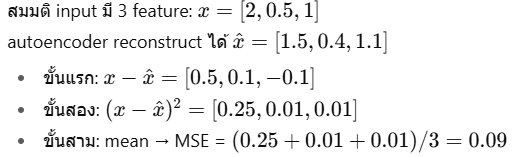

https://www.softnix.co.th/2020/03/24/anomaly-detection-part-5-autoencoder/

## Novelty Detection

### Prep data

In [9]:
df_transformed = expand_rule_columns(mock1)
df_transformed

function: expand_rule_columns is starting...
function: expand_rule_columns successfully executed at 0.3783261775970459s


,sales_id,expected_dt,flag_fraud,rule_10_l12,rule_10_l24,rule_10_l3,rule_10_l36,rule_10_l6,rule_10_l9,rule_1_l12,...,rule_8_l3,rule_8_l36,rule_8_l6,rule_8_l9,rule_9_l12,rule_9_l24,rule_9_l3,rule_9_l36,rule_9_l6,rule_9_l9
0,0,2024-12-30,0,1.294071,-0.033099,-0.771890,1.027978,-1.716319,-0.438359,-0.844588,...,-0.977754,-1.817574,-1.378777,-0.720249,-0.153002,0.147629,-0.051581,-1.928613,-1.005889,-1.700068
1,1,2024-07-14,1,2.970241,1.546394,1.960721,0.327022,1.395264,2.302689,2.134491,...,3.658322,2.169982,4.625339,4.100241,5.391337,4.974683,2.477348,5.201170,0.888200,0.345258
2,2,2025-05-26,0,-0.962456,0.007673,0.406085,-0.324495,-0.351193,-0.073130,-1.225513,...,1.040642,-0.017216,3.053033,1.115441,-2.003674,-0.515232,0.347390,1.687974,-0.886053,0.373724
3,3,2025-05-25,0,-0.557176,0.152205,0.339529,0.084018,0.929277,0.426988,0.121433,...,-0.063098,1.076034,-0.388208,1.075950,-0.600473,-2.693087,0.062432,-0.566217,0.786089,1.194925
4,4,2025-06-17,0,-0.822350,-0.840434,0.081125,-0.962901,-0.471622,-0.433285,1.266659,...,0.140467,-1.761751,-0.281367,1.718366,0.989666,-0.659094,-1.124522,-0.808209,-1.347342,0.004178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,2024-07-01,0,1.743071,-0.215017,-0.953072,-1.019967,-0.682181,1.137971,-0.507696,...,-0.945883,-1.856022,-1.172909,0.589566,0.158376,0.376485,-1.294563,-0.773980,0.137205,-0.786161
9996,9996,2025-05-03,0,0.185918,0.366925,-0.035507,0.955931,-0.901071,-0.267223,-1.110620,...,0.152714,-0.559135,-0.246215,0.267680,-0.556548,1.367107,0.888219,-0.084692,-0.196889,-2.770211
9997,9997,2024-10-22,0,-1.890159,-0.300070,0.348756,-1.058655,1.505729,0.651137,1.225570,...,0.762028,-0.696574,1.745624,-2.129891,0.216331,-1.248463,1.035880,-1.674949,0.124384,-0.070152
9998,9998,2024-11-24,0,-0.321089,0.573540,-0.461097,0.654136,0.506189,-1.361413,0.461321,...,-1.386205,-1.467512,-1.396175,0.997792,0.060714,0.336269,0.143255,-0.240759,-2.010408,-1.628413


In [10]:
df_subset = subset_by_timeunit(df_transformed, ["l3"])
df_subset

function: subset_by_timeunit is starting...
function: subset_by_timeunit successfully executed at 0.0014712810516357422s


,sales_id,expected_dt,flag_fraud,rule_10_l3,rule_1_l3,rule_2_l3,rule_3_l3,rule_4_l3,rule_5_l3,rule_6_l3,rule_7_l3,rule_8_l3,rule_9_l3
0,0,2024-12-30,0,-0.771890,0.360016,-0.228151,0.282450,-0.724385,-0.585063,1.173842,-1.051548,-0.977754,-0.051581
1,1,2024-07-14,1,1.960721,2.272585,-0.017009,5.743308,2.880759,5.058952,4.337591,-0.622909,3.658322,2.477348
2,2,2025-05-26,0,0.406085,1.024774,0.908937,-0.997060,-1.057251,-0.411173,-0.026746,-0.657898,1.040642,0.347390
3,3,2025-05-25,0,0.339529,-1.266539,1.167291,-2.820169,0.834055,0.934312,-0.432401,1.272910,-0.063098,0.062432
4,4,2025-06-17,0,0.081125,3.186575,1.344434,0.701131,-0.912804,0.143590,-0.813124,0.822111,0.140467,-1.124522
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,2024-07-01,0,-0.953072,1.243766,-0.907179,-1.908215,0.990946,-1.512523,-0.014095,1.904482,-0.945883,-1.294563
9996,9996,2025-05-03,0,-0.035507,-1.228504,-1.106326,-1.538331,0.971160,-1.681851,0.651500,-1.649923,0.152714,0.888219
9997,9997,2024-10-22,0,0.348756,-1.213162,-0.045952,-0.537501,-0.188053,-1.289207,0.359176,-0.278025,0.762028,1.035880
9998,9998,2024-11-24,0,-0.461097,-0.321970,-0.769184,-0.872505,0.332159,0.518029,-0.134807,-0.013322,-1.386205,0.143255


In [11]:
# train_all_df, test_df = split_train_test(df_subset)
train_all_df, test_df = split_train_test(df_transformed)

function: split_train_test is starting...
function: split_train_test successfully executed at 0.011630058288574219s


In [12]:
train_all_df

,sales_id,expected_dt,flag_fraud,rule_10_l12,rule_10_l24,rule_10_l3,rule_10_l36,rule_10_l6,rule_10_l9,rule_1_l12,...,rule_8_l3,rule_8_l36,rule_8_l6,rule_8_l9,rule_9_l12,rule_9_l24,rule_9_l3,rule_9_l36,rule_9_l6,rule_9_l9
0,3630,2025-01-09,0,0.789581,-0.571427,-0.122792,1.004332,-0.273505,1.467974,1.307835,...,-0.907257,-0.707563,0.585907,0.544456,-0.782449,-0.798530,0.067369,-0.737219,-1.108168,-0.294903
1,5986,2024-09-11,0,0.369698,-1.136322,-1.810910,-2.192158,1.280891,-0.709141,1.903261,...,-0.289624,-0.090674,0.322351,0.197199,0.375892,-0.920409,-1.331525,-0.016277,-1.086676,0.270081
2,7036,2025-05-28,0,-0.390536,-0.263824,1.651168,-0.772366,0.359175,0.560699,-0.389963,...,-0.391907,-0.321691,-1.234105,-0.487193,-1.103392,-0.185892,-1.567152,0.135463,0.962213,0.308523
3,628,2025-01-09,0,1.297024,0.606710,-1.085953,-0.055662,-0.690931,1.140741,-0.883268,...,-0.071813,-0.824542,-0.415301,0.355717,1.303947,-0.099803,-2.672207,-0.923486,0.883586,1.884059
4,6352,2024-11-30,0,0.382092,0.948331,-1.097125,-0.251941,-1.197393,-0.227360,-0.023993,...,0.048710,-1.671467,0.076069,-0.494949,0.817704,0.111234,-0.708750,-1.267475,-0.609939,-1.320383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,9252,2024-12-25,0,0.610312,0.558819,-1.534743,1.486011,1.223751,0.098766,0.025065,...,1.298804,0.265428,0.257803,1.626610,-1.033954,-0.094529,0.859581,0.989420,-0.130922,-1.050537
7996,5428,2024-12-16,0,0.134426,-0.602359,0.456768,0.098359,1.229681,0.131934,0.275289,...,0.311049,0.071579,-0.882040,-0.030939,1.684502,1.507108,-1.798395,-0.834150,-0.703484,0.368902
7997,5860,2025-02-21,0,-1.040665,-2.199427,-1.223507,1.150970,2.554480,-1.149629,0.530495,...,-1.006606,-1.810087,-1.349829,1.591222,1.262590,0.002762,0.331927,-0.340371,0.690682,1.147406
7998,5684,2025-05-12,0,-0.726755,-0.300747,-0.335984,-2.168752,-0.771411,-0.110201,0.753100,...,-1.383170,-1.882080,0.352121,-0.705427,1.382900,0.184316,0.014605,0.002375,-0.678729,-0.130359


In [13]:
train_all_df['flag_fraud'].value_counts()

flag_fraud
0    7621
1     379
Name: count, dtype: int64

In [14]:
train_all_df['flag_fraud'].value_counts(normalize=True)

flag_fraud
0    0.952625
1    0.047375
Name: proportion, dtype: float64

In [15]:
test_df

,sales_id,expected_dt,flag_fraud,rule_10_l12,rule_10_l24,rule_10_l3,rule_10_l36,rule_10_l6,rule_10_l9,rule_1_l12,...,rule_8_l3,rule_8_l36,rule_8_l6,rule_8_l9,rule_9_l12,rule_9_l24,rule_9_l3,rule_9_l36,rule_9_l6,rule_9_l9
0,8751,2024-12-26,0,0.798646,1.910989,-0.682210,0.424926,-1.310464,-0.159852,1.026974,...,-0.293970,-0.800502,0.415709,0.394036,-0.842713,1.256972,0.869192,-1.737545,-0.519668,-0.816122
1,3108,2024-11-01,0,-0.555605,0.730730,1.181475,-0.037051,1.372782,-0.862182,0.231596,...,-0.684921,-1.646365,-0.472107,-0.325467,1.423782,0.915487,-0.360646,0.227369,1.185418,-0.617715
2,7395,2025-05-09,0,-2.177425,1.464783,0.949450,-2.652735,-0.323935,-0.288479,1.572847,...,-0.835385,1.554332,-0.070805,-0.733257,-0.903604,0.163703,0.361375,0.620957,-0.306494,-1.036489
3,1373,2024-08-04,0,-0.074699,-1.011416,-0.316521,0.904059,-0.085413,-0.956141,1.158787,...,0.812321,0.411823,0.964708,-0.823430,-1.245430,-0.561469,-0.406162,-0.621298,1.358561,0.600808
4,1858,2024-11-11,0,0.751402,0.627102,1.177705,-1.458779,-1.420252,0.408476,0.911883,...,-0.080884,-0.020651,0.819578,-0.832959,1.338492,0.330601,0.517684,0.712518,0.574394,1.251943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,3178,2025-04-29,0,-1.137132,0.194624,-0.176596,-1.727917,0.854812,0.089249,0.135637,...,-0.585872,-0.716755,-1.262167,-0.396327,-0.640715,-1.009249,-0.336405,0.919093,-0.277911,1.903558
1996,9980,2025-02-08,0,-0.213127,-0.605733,-1.569894,0.152895,0.959610,-0.700119,2.420643,...,0.301153,0.348440,1.092087,0.947833,0.790195,0.175799,0.616660,0.008679,0.867330,0.971056
1997,1440,2025-02-17,1,3.401023,0.446424,6.905169,3.912749,2.055033,-0.537756,5.523634,...,3.261699,4.511497,4.965434,1.237663,1.668512,5.471353,-1.403755,4.089967,3.763217,0.479352
1998,8684,2024-12-05,0,-2.256141,-0.652300,-0.467944,-0.007293,0.371925,0.962237,0.103078,...,0.511378,-0.926029,0.372627,-0.689930,0.758842,-0.504341,1.455674,0.441432,-1.449011,0.748324


In [16]:
test_df['flag_fraud'].value_counts()

flag_fraud
0    1905
1      95
Name: count, dtype: int64

In [17]:
test_df['flag_fraud'].value_counts(normalize=True)

flag_fraud
0    0.9525
1    0.0475
Name: proportion, dtype: float64

# Start ตรงนี้หลังรับ Data มาจากฝ้าย

In [18]:
train_all_df

,sales_id,expected_dt,flag_fraud,rule_10_l12,rule_10_l24,rule_10_l3,rule_10_l36,rule_10_l6,rule_10_l9,rule_1_l12,...,rule_8_l3,rule_8_l36,rule_8_l6,rule_8_l9,rule_9_l12,rule_9_l24,rule_9_l3,rule_9_l36,rule_9_l6,rule_9_l9
0,3630,2025-01-09,0,0.789581,-0.571427,-0.122792,1.004332,-0.273505,1.467974,1.307835,...,-0.907257,-0.707563,0.585907,0.544456,-0.782449,-0.798530,0.067369,-0.737219,-1.108168,-0.294903
1,5986,2024-09-11,0,0.369698,-1.136322,-1.810910,-2.192158,1.280891,-0.709141,1.903261,...,-0.289624,-0.090674,0.322351,0.197199,0.375892,-0.920409,-1.331525,-0.016277,-1.086676,0.270081
2,7036,2025-05-28,0,-0.390536,-0.263824,1.651168,-0.772366,0.359175,0.560699,-0.389963,...,-0.391907,-0.321691,-1.234105,-0.487193,-1.103392,-0.185892,-1.567152,0.135463,0.962213,0.308523
3,628,2025-01-09,0,1.297024,0.606710,-1.085953,-0.055662,-0.690931,1.140741,-0.883268,...,-0.071813,-0.824542,-0.415301,0.355717,1.303947,-0.099803,-2.672207,-0.923486,0.883586,1.884059
4,6352,2024-11-30,0,0.382092,0.948331,-1.097125,-0.251941,-1.197393,-0.227360,-0.023993,...,0.048710,-1.671467,0.076069,-0.494949,0.817704,0.111234,-0.708750,-1.267475,-0.609939,-1.320383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,9252,2024-12-25,0,0.610312,0.558819,-1.534743,1.486011,1.223751,0.098766,0.025065,...,1.298804,0.265428,0.257803,1.626610,-1.033954,-0.094529,0.859581,0.989420,-0.130922,-1.050537
7996,5428,2024-12-16,0,0.134426,-0.602359,0.456768,0.098359,1.229681,0.131934,0.275289,...,0.311049,0.071579,-0.882040,-0.030939,1.684502,1.507108,-1.798395,-0.834150,-0.703484,0.368902
7997,5860,2025-02-21,0,-1.040665,-2.199427,-1.223507,1.150970,2.554480,-1.149629,0.530495,...,-1.006606,-1.810087,-1.349829,1.591222,1.262590,0.002762,0.331927,-0.340371,0.690682,1.147406
7998,5684,2025-05-12,0,-0.726755,-0.300747,-0.335984,-2.168752,-0.771411,-0.110201,0.753100,...,-1.383170,-1.882080,0.352121,-0.705427,1.382900,0.184316,0.014605,0.002375,-0.678729,-0.130359


In [19]:
test_df

,sales_id,expected_dt,flag_fraud,rule_10_l12,rule_10_l24,rule_10_l3,rule_10_l36,rule_10_l6,rule_10_l9,rule_1_l12,...,rule_8_l3,rule_8_l36,rule_8_l6,rule_8_l9,rule_9_l12,rule_9_l24,rule_9_l3,rule_9_l36,rule_9_l6,rule_9_l9
0,8751,2024-12-26,0,0.798646,1.910989,-0.682210,0.424926,-1.310464,-0.159852,1.026974,...,-0.293970,-0.800502,0.415709,0.394036,-0.842713,1.256972,0.869192,-1.737545,-0.519668,-0.816122
1,3108,2024-11-01,0,-0.555605,0.730730,1.181475,-0.037051,1.372782,-0.862182,0.231596,...,-0.684921,-1.646365,-0.472107,-0.325467,1.423782,0.915487,-0.360646,0.227369,1.185418,-0.617715
2,7395,2025-05-09,0,-2.177425,1.464783,0.949450,-2.652735,-0.323935,-0.288479,1.572847,...,-0.835385,1.554332,-0.070805,-0.733257,-0.903604,0.163703,0.361375,0.620957,-0.306494,-1.036489
3,1373,2024-08-04,0,-0.074699,-1.011416,-0.316521,0.904059,-0.085413,-0.956141,1.158787,...,0.812321,0.411823,0.964708,-0.823430,-1.245430,-0.561469,-0.406162,-0.621298,1.358561,0.600808
4,1858,2024-11-11,0,0.751402,0.627102,1.177705,-1.458779,-1.420252,0.408476,0.911883,...,-0.080884,-0.020651,0.819578,-0.832959,1.338492,0.330601,0.517684,0.712518,0.574394,1.251943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,3178,2025-04-29,0,-1.137132,0.194624,-0.176596,-1.727917,0.854812,0.089249,0.135637,...,-0.585872,-0.716755,-1.262167,-0.396327,-0.640715,-1.009249,-0.336405,0.919093,-0.277911,1.903558
1996,9980,2025-02-08,0,-0.213127,-0.605733,-1.569894,0.152895,0.959610,-0.700119,2.420643,...,0.301153,0.348440,1.092087,0.947833,0.790195,0.175799,0.616660,0.008679,0.867330,0.971056
1997,1440,2025-02-17,1,3.401023,0.446424,6.905169,3.912749,2.055033,-0.537756,5.523634,...,3.261699,4.511497,4.965434,1.237663,1.668512,5.471353,-1.403755,4.089967,3.763217,0.479352
1998,8684,2024-12-05,0,-2.256141,-0.652300,-0.467944,-0.007293,0.371925,0.962237,0.103078,...,0.511378,-0.926029,0.372627,-0.689930,0.758842,-0.504341,1.455674,0.441432,-1.449011,0.748324


In [20]:
train_t_df = train_all_df.drop(columns='expected_dt')
train_t_df

,sales_id,flag_fraud,rule_10_l12,rule_10_l24,rule_10_l3,rule_10_l36,rule_10_l6,rule_10_l9,rule_1_l12,rule_1_l24,...,rule_8_l3,rule_8_l36,rule_8_l6,rule_8_l9,rule_9_l12,rule_9_l24,rule_9_l3,rule_9_l36,rule_9_l6,rule_9_l9
0,3630,0,0.789581,-0.571427,-0.122792,1.004332,-0.273505,1.467974,1.307835,-1.315621,...,-0.907257,-0.707563,0.585907,0.544456,-0.782449,-0.798530,0.067369,-0.737219,-1.108168,-0.294903
1,5986,0,0.369698,-1.136322,-1.810910,-2.192158,1.280891,-0.709141,1.903261,2.141594,...,-0.289624,-0.090674,0.322351,0.197199,0.375892,-0.920409,-1.331525,-0.016277,-1.086676,0.270081
2,7036,0,-0.390536,-0.263824,1.651168,-0.772366,0.359175,0.560699,-0.389963,-0.142301,...,-0.391907,-0.321691,-1.234105,-0.487193,-1.103392,-0.185892,-1.567152,0.135463,0.962213,0.308523
3,628,0,1.297024,0.606710,-1.085953,-0.055662,-0.690931,1.140741,-0.883268,-1.210047,...,-0.071813,-0.824542,-0.415301,0.355717,1.303947,-0.099803,-2.672207,-0.923486,0.883586,1.884059
4,6352,0,0.382092,0.948331,-1.097125,-0.251941,-1.197393,-0.227360,-0.023993,-0.189681,...,0.048710,-1.671467,0.076069,-0.494949,0.817704,0.111234,-0.708750,-1.267475,-0.609939,-1.320383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,9252,0,0.610312,0.558819,-1.534743,1.486011,1.223751,0.098766,0.025065,-0.122803,...,1.298804,0.265428,0.257803,1.626610,-1.033954,-0.094529,0.859581,0.989420,-0.130922,-1.050537
7996,5428,0,0.134426,-0.602359,0.456768,0.098359,1.229681,0.131934,0.275289,-0.661305,...,0.311049,0.071579,-0.882040,-0.030939,1.684502,1.507108,-1.798395,-0.834150,-0.703484,0.368902
7997,5860,0,-1.040665,-2.199427,-1.223507,1.150970,2.554480,-1.149629,0.530495,-2.114538,...,-1.006606,-1.810087,-1.349829,1.591222,1.262590,0.002762,0.331927,-0.340371,0.690682,1.147406
7998,5684,0,-0.726755,-0.300747,-0.335984,-2.168752,-0.771411,-0.110201,0.753100,0.142161,...,-1.383170,-1.882080,0.352121,-0.705427,1.382900,0.184316,0.014605,0.002375,-0.678729,-0.130359


In [21]:
test_t_df = test_df.drop(columns='expected_dt')
test_t_df

,sales_id,flag_fraud,rule_10_l12,rule_10_l24,rule_10_l3,rule_10_l36,rule_10_l6,rule_10_l9,rule_1_l12,rule_1_l24,...,rule_8_l3,rule_8_l36,rule_8_l6,rule_8_l9,rule_9_l12,rule_9_l24,rule_9_l3,rule_9_l36,rule_9_l6,rule_9_l9
0,8751,0,0.798646,1.910989,-0.682210,0.424926,-1.310464,-0.159852,1.026974,-0.799381,...,-0.293970,-0.800502,0.415709,0.394036,-0.842713,1.256972,0.869192,-1.737545,-0.519668,-0.816122
1,3108,0,-0.555605,0.730730,1.181475,-0.037051,1.372782,-0.862182,0.231596,0.982961,...,-0.684921,-1.646365,-0.472107,-0.325467,1.423782,0.915487,-0.360646,0.227369,1.185418,-0.617715
2,7395,0,-2.177425,1.464783,0.949450,-2.652735,-0.323935,-0.288479,1.572847,-0.418961,...,-0.835385,1.554332,-0.070805,-0.733257,-0.903604,0.163703,0.361375,0.620957,-0.306494,-1.036489
3,1373,0,-0.074699,-1.011416,-0.316521,0.904059,-0.085413,-0.956141,1.158787,-0.447172,...,0.812321,0.411823,0.964708,-0.823430,-1.245430,-0.561469,-0.406162,-0.621298,1.358561,0.600808
4,1858,0,0.751402,0.627102,1.177705,-1.458779,-1.420252,0.408476,0.911883,0.318527,...,-0.080884,-0.020651,0.819578,-0.832959,1.338492,0.330601,0.517684,0.712518,0.574394,1.251943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,3178,0,-1.137132,0.194624,-0.176596,-1.727917,0.854812,0.089249,0.135637,-0.328038,...,-0.585872,-0.716755,-1.262167,-0.396327,-0.640715,-1.009249,-0.336405,0.919093,-0.277911,1.903558
1996,9980,0,-0.213127,-0.605733,-1.569894,0.152895,0.959610,-0.700119,2.420643,-1.251015,...,0.301153,0.348440,1.092087,0.947833,0.790195,0.175799,0.616660,0.008679,0.867330,0.971056
1997,1440,1,3.401023,0.446424,6.905169,3.912749,2.055033,-0.537756,5.523634,2.935200,...,3.261699,4.511497,4.965434,1.237663,1.668512,5.471353,-1.403755,4.089967,3.763217,0.479352
1998,8684,0,-2.256141,-0.652300,-0.467944,-0.007293,0.371925,0.962237,0.103078,0.599366,...,0.511378,-0.926029,0.372627,-0.689930,0.758842,-0.504341,1.455674,0.441432,-1.449011,0.748324


In [22]:
(all_df, X_scaled_all, y_all , 
train_all_df, X_scaled_train_all,y_train_all,
train_nonfraud_df, X_scaled_train_nonfraud, y_train_nonfraud, 
X_scaled_train, X_scaled_val, X_scaled_test, y_test) = prepare_train_val_test_data(train_df=train_t_df, 
                                                                                    test_df=test_t_df, 
                                                                                    pk="sales_id", 
                                                                                    date_col="expected_dt",
                                                                                    target="flag_fraud",
                                                                                    val_size=0.2, 
                                                                                    random_state=42, 
                                                                                    scale=True)

function: prepare_train_val_test_data is starting...
Data Prepared:
all_df            : (10000, 62)
X_all             : (10000, 60), y_all: (10000,)
train_all_df      : (8000, 62)
X_train_all       : (8000, 60), y_train_all: (8000,)
train_nonfraud_df : (7621, 62)
X_train_nonfraud  : (7621, 60), y_train_nonfraud: (7621,)
X_train           : (6096, 60)
X_val             : (1525, 60)
X_test            : (2000, 60), y_test: (2000,)
--------------------------------------------------
function: prepare_train_val_test_data successfully executed at 0.0616302490234375s


In [23]:
# Task Train
X_scaled_train.shape # Train on non-fraud only

(6096, 60)

In [24]:
# Task Train
X_scaled_val.shape # val non-fraud only (sep from train)

(1525, 60)

In [25]:
# Task Lookup Threshold 
X_scaled_train_all.shape # All Train Dataset

(8000, 60)

In [26]:
# Task Lookup Threshold 
y_train_all.shape # All Train Dataset - Non Fraud

(8000,)

In [27]:
# Task Lookup Threshold
train_all_df.shape # All Train Dataset for key

(8000, 62)

In [28]:
# Task Evaluate
X_scaled_test.shape # Test on all agent, even if it contains fraud, because you’re looking at the reconstruction error to flag anomalies

(2000, 60)

In [29]:
# Task Evaluate
y_test.shape

(2000,)

In [30]:
# Task Visualize
X_scaled_all.shape # all dataset train+test

(10000, 60)

In [31]:
# Task Visualize
y_all.shape # all dataset train+test

(10000,)

In [32]:
# Task Visualize
all_df.shape # all dataset train+test for key

(10000, 62)

In [33]:
true_fraud_test_list = test_df.loc[test_df['flag_fraud']==1,'sales_id'].to_list()
true_fraud_train_all_list = train_all_df.loc[train_all_df['flag_fraud']==1,'sales_id'].to_list()
true_fraud_list = true_fraud_test_list + true_fraud_train_all_list
len(true_fraud_list)

474

# Task Train

### defining the architecture of the autoencoder
- Building the layers (nn.Linear, nn.ReLU, etc.)
- Structuring the encoder and decoder using nn.Sequential
- Defining the forward() function for how data flows through the network
  <br><br>
**But this does not train anything yet.**

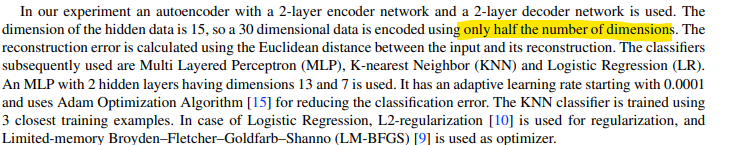

In [34]:
# design arch
in_x = X_scaled_train.shape[1] # จำนวน features -> input_dim
h1 = X_scaled_train.shape[1]//2 #  -> number of neuron in hidden layer 1
h2 = X_scaled_train.shape[1]//4 # -> hidden 2
h3 = X_scaled_train.shape[1]//8 # -> hidden 3

print(f'input layer dim = {in_x}')
print(f'hidden layer dim #1 = {h1}')
print(f'hidden layer dim #2 = {h2}')
print(f'hidden layer dim #3 = {h3}')

input layer dim = 60
hidden layer dim #1 = 30
hidden layer dim #2 = 15
hidden layer dim #3 = 7


In [35]:
from torchinfo import summary
set_seed(42)

model_ae = Autoencoder(input_dim=in_x, 
                         encoding_dim=3, 
                         hidden_layers=[h1, 
                                        h2,
                                        h3,
                                       ],
                         dropout=0.2,
                         verbose=False
                        )

# This is only used for testing the model architecture, not training or evaluating on real data.
dummy_input = torch.randn(5, X_scaled_train.shape[1]) 
summary(model_ae, input_data=dummy_input, verbose=0)

function: set_seed is starting...
function: set_seed successfully executed at 0.003215789794921875s


Layer (type:depth-idx)                   Output Shape              Param #
Autoencoder                              [5, 60]                   --
├─Sequential: 1-1                        --                        --
│    └─Linear: 2-1                       [5, 30]                   1,830
│    └─ReLU: 2-2                         [5, 30]                   --
│    └─Dropout: 2-3                      [5, 30]                   --
│    └─Linear: 2-4                       [5, 15]                   465
│    └─ReLU: 2-5                         [5, 15]                   --
│    └─Dropout: 2-6                      [5, 15]                   --
│    └─Linear: 2-7                       [5, 7]                    112
│    └─ReLU: 2-8                         [5, 7]                    --
│    └─Dropout: 2-9                      [5, 7]                    --
│    └─Linear: 2-10                      [5, 3]                    24
├─Sequential: 1-2                        --                        --
│    └─Lin

#### train model to learn normal pattern
It trains an Autoencoder model to reconstruct its input, using mean squared error (MSE) as the loss. 
This lets the model learn the “normal pattern” of your data which you'll later use to detect anomalies.

#### loss  function and optimizer

https://docs.pytorch.org/docs/stable/nn.html#loss-functions

https://medium.com/@chalat.phum/mse-rmse-mae-%E0%B9%80%E0%B8%A5%E0%B8%B7%E0%B8%AD%E0%B8%81%E0%B9%83%E0%B8%8A%E0%B9%89%E0%B8%A2%E0%B8%B1%E0%B8%87%E0%B9%84%E0%B8%87%E0%B8%94%E0%B8%B5%E0%B8%A1%E0%B8%B2%E0%B8%A5%E0%B8%AD%E0%B8%87%E0%B8%94%E0%B8%B9%E0%B8%97%E0%B8%B5%E0%B9%88%E0%B8%84%E0%B8%A7%E0%B8%B2%E0%B8%A1%E0%B8%AB%E0%B8%A1%E0%B8%B2%E0%B8%A2-17b37b0b14b3

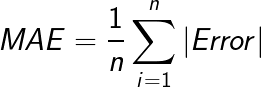

default : MAE เพราะ
1. Robust to Outliers – MAE จะไม่ขยายค่า error ของ outlier ให้มากเกินไปเหมือน MSE (Mean Squared Error) ทำให้ autoencoder ไม่ถูก bias โดยค่าผิดปกติที่รุนแรง ซึ่งเหมาะกับ fraud detection ที่ anomaly มักจะเป็น extreme values

2. Interpretability – ค่าของ MAE ตีความได้ง่ายกว่า เพราะเป็นค่าเฉลี่ยของ absolute difference ระหว่าง input และ reconstruction ทำให้ threshold ในการตัดสิน fraud/non-fraud ดูตรงไปตรงมากว่า

3. Stable Reconstruction Error – MAE ช่วยให้ reconstruction error มีความกระจาย (distribution) ที่ค่อนข้างสม่ำเสมอ ไม่ถูกดันให้ skewed เหมือน MSE ซึ่งจะทำให้การแยกปกติ vs anomaly ด้วย threshold ชัดเจนขึ้น

| **Loss Function**                                          | **When to Use / Pros**                                                                                                     | **PyTorch Implementation**                      |
| ---------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------- |
| **Mean Squared Error (MSE)** (`nn.MSELoss()`)              | Default for continuous features. Penalizes larger errors more. Good when reconstruction of numeric values matters.         | `loss_fn = nn.MSELoss()`                        |
| **Mean Absolute Error (MAE)** (`nn.L1Loss()`)              | More robust to outliers than MSE. Good if anomalies have very large deviations and you don’t want them to dominate.        | `loss_fn = nn.L1Loss()`                         |
| **Huber Loss (Smooth L1)** (`nn.SmoothL1Loss()`)           | A mix of MSE and MAE. Linear for small errors, quadratic for large ones. Balanced robustness.                              | `loss_fn = nn.SmoothL1Loss(beta=1.0)`           |
| **Binary Cross-Entropy (BCE)** (`nn.BCELoss()`)            | Use when inputs are binary or scaled \[0,1]. Common in **image autoencoders (pixel intensity)**.                           | `loss_fn = nn.BCELoss()`                        |
| **BCE with Logits** (`nn.BCEWithLogitsLoss()`)             | Same as BCE but more numerically stable (avoids log(0)). Use if your decoder doesn’t already apply `sigmoid()`.            | `loss_fn = nn.BCEWithLogitsLoss()`              |
| **Kullback-Leibler Divergence (KLDiv)** (`nn.KLDivLoss()`) | Used in **Variational Autoencoders (VAE)** to regularize latent space. Not standalone — combined with reconstruction loss. | `loss_fn = nn.KLDivLoss(reduction="batchmean")` |
| **Cosine Similarity Loss** (`nn.CosineEmbeddingLoss`)      | Useful if you care about *direction* of vectors (embeddings) rather than magnitude.                                        | `loss_fn = nn.CosineEmbeddingLoss()`            |
| **Custom Weighted Loss**                                   | Weight certain features more (e.g., categorical vs numerical).                                                             | `loss = torch.mean(weights * (x - x_hat)**2)`   |


https://docs.pytorch.org/docs/stable/optim.html

default : Adam

| Optimizer                     | Description / When to Use                                                                      |
| ----------------------------- | ---------------------------------------------------------------------------------------------- |
| **Adam** (`optim.Adam`)       | Default choice for autoencoders; adaptive learning rate, generally stable and fast.            |
| **AdamW** (`optim.AdamW`)     | Variant of Adam with better weight decay handling; improves regularization for dense networks. |
| **RMSProp** (`optim.RMSprop`) | Can help stabilize training if gradients are noisy; sometimes useful for deeper autoencoders.  |

In PyTorch, tensors are the main data structure for storing inputs, outputs, and model parameters.
<br>
A device is the hardware that will do computations with these tensors: <br>
CPU: your computer’s main processor. <br>
GPU: a specialized processor for fast parallel computations (much faster for deep learning).
<br>
Every tensor and model must be on the same device for training.

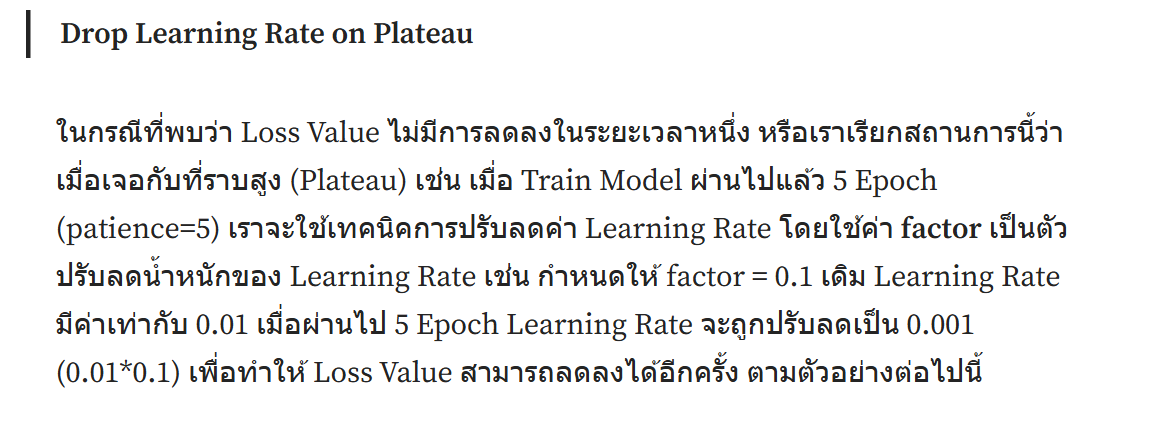

In [36]:
set_seed(42)
trained_model, train_losses, val_losses = train_autoencoder_checkpoint(
    model = model_ae, 
    X_train = X_scaled_train, 
    X_val = X_scaled_val, 
    epochs=20, 
    checkpoint_every=10, 
    early_stopping_patience=10,
    run_dir="model_checkpoint",
    loss_name="mae", 
    optimizer_name="adam",
    scheduler_name=None,
    # scheduler_name="plateau",
    # scheduler_params=None,
    # scheduler_params={"factor": 0.2, "patience": 3
    #                   # ,"step_size":5
    #                  }
)

function: set_seed is starting...
function: set_seed successfully executed at 0.0046651363372802734s
function: train_autoencoder_checkpoint is starting...
[INFO] Using device: cpu
[INFO] DataLoader seed info:
       Global generator manual_seed: 42
       Torch initial seed: 42
       Generator state (deterministic): True
       Benchmark mode: False
[INFO] Using loss function: L1Loss
[INFO] Using optimizer: Adam, LR: 0.001000
[INFO] Scheduler not used.
Epoch [1/20] - Train Loss: 0.7994, Val Loss: 0.7979
Epoch [2/20] - Train Loss: 0.7955, Val Loss: 0.7949
Epoch [3/20] - Train Loss: 0.7938, Val Loss: 0.7941
Epoch [4/20] - Train Loss: 0.7931, Val Loss: 0.7939
Epoch [5/20] - Train Loss: 0.7927, Val Loss: 0.7935
Epoch [6/20] - Train Loss: 0.7921, Val Loss: 0.7933
Epoch [7/20] - Train Loss: 0.7913, Val Loss: 0.7924
Epoch [8/20] - Train Loss: 0.7907, Val Loss: 0.7915
Epoch [9/20] - Train Loss: 0.7902, Val Loss: 0.7911
Epoch [10/20] - Train Loss: 0.7900, Val Loss: 0.7907
function: save_checkp

In [37]:
# resume case

# trained_model, train_losses, val_losses = train_autoencoder_checkpoint(
#         model = model_ae, 
#         X_train = X_scaled_train, 
#         X_val = X_scaled_val, 
#         epochs=120, 
#         checkpoint_every=20, 
#         checkpoint_path=r"model_checkpoint\20250814_164332\checkpoint_epoch99.pkl",
#         early_stopping_patience=10,
#         )

In [38]:
# trained_model, train_losses, val_losses, last_epoch = load_pickled_autoencoder(
#     r"model_checkpoint\20250814_164332\checkpoint_epoch99.pkl",
#     model=model_ae,
#     device=torch.device('cpu')
# )

In [39]:
trained_model

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=60, out_features=30, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=30, out_features=15, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=15, out_features=7, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=7, out_features=3, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=3, out_features=7, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=7, out_features=15, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=15, out_features=30, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=30, out_features=60, bias=True)
  )
)

In [40]:
# set_seed(42)
# trained_model , train_losses, val_losses= train_autoencoder(model=model_ae, 
#                                                             X_train=X_scaled_train,
#                                                             X_val = X_scaled_val, 
#                                                             epochs=50, 
#                                                             batch_size=64)

What the graph shows:
- X-axis: Epochs (how many times the model has seen the training data)
- Y-axis: Loss (how well the model reconstructs input — lower is better)

There are two curves:
- Training Loss: Error on the training data the model learned from
- Validation Loss: Error on unseen data (validation set)

Goal: Both losses should decrease and stay close to each other.

If validation loss starts increasing while training loss decreases, it’s a sign to stop training or apply techniques to reduce overfitting.

function: plot_learning_curve is starting...


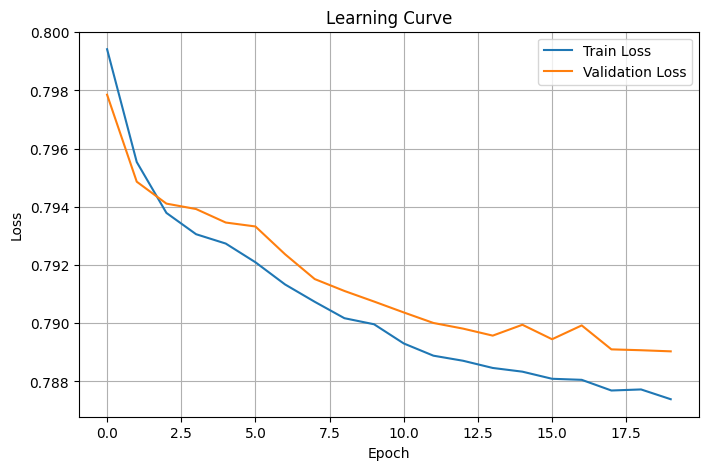

function: plot_learning_curve successfully executed at 0.13605451583862305s


In [41]:
plot_learning_curve(train_losses, val_losses)

### Grid search - skip รันนานเกิน เอาเวลาไปเพิ่ม epoch

| Parameter      | What it controls                  | Why tune it?                         |
| -------------- | --------------------------------- | ------------------------------------ |
| encoding\_dim  | Size of compressed representation | Balance between detail & compression |
| hidden\_layers | Number & size of layers in model  | Model complexity & learning power    |
| activation     | Function deciding neuron output   | How model learns patterns            |
| batch\_size    | Number of samples per update      | Stability & speed of training        |
| lr             | Step size for weight updates      | Training speed & convergence         |


In [42]:
# param_grid = {
#     "encoding_dim": [2, 3, 4],
#     "hidden_layers": [[8], [8, 4], [16, 8]],
#     "activation": [nn.ReLU, nn.Tanh],
#     "batch_size": [32, 64],
#     "lr": [1e-3, 5e-4]
# }

## รันนานมาก ขอคอมมเม้นไว้ก่อน
# best_model, best_config, best_val_loss = tune_autoencoder_grid(
#     X_train=X_train,    # your normal train data (numpy or pd.DataFrame)
#     X_val=X_val,        # your normal validation data (numpy or pd.DataFrame)
#     param_grid=param_grid,
#     epochs=50,
#     verbose=True
# )

# print("Best config found:", best_config)

# Task Lookup Threshold 

### Predict and Test Performance

- หลังจากได้โมเดล เราลองใส่ X_scaled_train_nonfraud เข้าไปเพื่อให้ได้  y_predict
- แล้วทดสอบผลกับ true_fraud_list

In [43]:
recon_error = get_reconstruction_error(trained_model, X_scaled_train_all,loss_name="mae")
recon_error

function: get_reconstruction_error is starting...
[INFO] Reconstruction error calculated using MAE for 8000 samples
[INFO] Error stats -> min: 0.5466, max: 3.7631, mean: 0.8935
function: get_reconstruction_error successfully executed at 0.008788824081420898s


array([0.75195295, 0.8583132 , 0.57116294, ..., 0.88611037, 0.8935304 ,
       0.7736941 ], shape=(8000,), dtype=float32)

In [44]:
X_scaled_train_all

,rule_10_l12,rule_10_l24,rule_10_l3,rule_10_l36,rule_10_l6,rule_10_l9,rule_1_l12,rule_1_l24,rule_1_l3,rule_1_l36,...,rule_8_l3,rule_8_l36,rule_8_l6,rule_8_l9,rule_9_l12,rule_9_l24,rule_9_l3,rule_9_l36,rule_9_l6,rule_9_l9
0,0.781991,-0.560466,-0.113512,1.018084,-0.268235,1.474837,1.295927,-1.319330,-0.356585,0.949133,...,-0.929623,-0.693300,0.564041,0.529473,-0.764982,-0.783341,0.063529,-0.748693,-1.105220,-0.293641
1,0.370138,-1.124187,-1.807820,-2.161642,1.296443,-0.673684,1.896395,2.155237,0.690995,1.380100,...,-0.303797,-0.083304,0.303517,0.181481,0.386287,-0.905138,-1.346002,-0.024458,-1.083728,0.272316
2,-0.375557,-0.253502,1.666952,-0.749296,0.368630,0.579478,-0.416250,-0.140122,0.866615,1.261036,...,-0.407437,-0.311739,-1.235039,-0.504359,-1.083966,-0.171115,-1.583421,0.127974,0.965250,0.310824
3,1.279729,0.615224,-1.080205,-0.036350,-0.688423,1.151902,-0.913733,-1.213227,0.722840,-0.780575,...,-0.083097,-0.808971,-0.425652,0.340335,1.308676,-0.085084,-2.696878,-0.935811,0.886620,1.889077
4,0.382294,0.956135,-1.091419,-0.231600,-1.198234,-0.198231,-0.047181,-0.187740,-1.424141,1.251307,...,0.039025,-1.646433,0.060067,-0.512130,0.825402,0.125811,-0.718492,-1.281370,-0.606970,-1.320889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,0.606150,0.567432,-1.530641,1.497238,1.238925,0.123612,0.002293,-0.120525,-0.084149,-0.366128,...,1.305701,0.268819,0.239711,1.613915,-1.014952,-0.079813,0.861765,0.985831,-0.127932,-1.050578
7996,0.139365,-0.591334,0.468173,0.116863,1.244895,0.156344,0.254636,-0.661731,-0.286355,-0.345954,...,0.304844,0.077136,-0.887023,-0.047139,1.686907,1.520747,-1.816422,-0.846067,-0.700519,0.371308
7997,-1.013252,-2.185082,-1.218263,1.163953,2.578457,-1.108387,0.512003,-2.122257,0.614396,-0.417708,...,-1.030290,-1.783504,-1.349433,1.578453,1.267571,0.017412,0.330099,-0.350033,0.693707,1.151154
7998,-0.705346,-0.290348,-0.327486,-2.138359,-0.769434,-0.082611,0.736493,0.145769,1.435556,0.905095,...,-1.411850,-1.854692,0.332944,-0.723054,1.387146,0.198844,0.010363,-0.005722,-0.675763,-0.128814


In [45]:
lookup_pct_threshold = evaluate_thresholds(x_scaled = X_scaled_train_all , 
                                            train_all_df=train_all_df ,
                                            y_train_all=y_train_all , 
                                            recon_error=recon_error ,
                                            true_fraud_list=true_fraud_list)

function: evaluate_thresholds is starting...
function: flag_anomalies is starting...
function: flag_anomalies successfully executed at 9.799003601074219e-05s
function: create_pack_results is starting...
function: create_pack_results successfully executed at 0.0004379749298095703s
function: flag_anomalies is starting...
function: flag_anomalies successfully executed at 3.647804260253906e-05s
function: create_pack_results is starting...
function: create_pack_results successfully executed at 0.0001499652862548828s
function: flag_anomalies is starting...
function: flag_anomalies successfully executed at 4.4345855712890625e-05s
function: create_pack_results is starting...
function: create_pack_results successfully executed at 0.0001761913299560547s
function: flag_anomalies is starting...
function: flag_anomalies successfully executed at 8.20159912109375e-05s
function: create_pack_results is starting...
function: create_pack_results successfully executed at 0.00038552284240722656s
function: 

100%|██████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 37.31it/s]

function: evaluate_fraud_predictions successfully executed at 0.3560338020324707s
function: evaluate_thresholds successfully executed at 0.3835732936859131s


In [46]:
lookup_pct_threshold

,experiments,total_alert,tp,fp,tn,fn,precision,recall,f0.5,f1
0,ae_default_all_p10,7237,379,6858,763,0,0.052370,1.0,0.064616,0.099527
1,ae_default_all_p20,6475,379,6096,1525,0,0.058533,1.0,0.072111,0.110592
2,ae_default_all_p30,5713,379,5334,2287,0,0.066340,1.0,0.081572,0.124425
3,ae_default_all_p40,4951,379,4572,3049,0,0.076550,1.0,0.093891,0.142214
4,ae_default_all_p50,4189,379,3810,3811,0,0.090475,1.0,0.110592,0.165937
5,ae_default_all_p60,3427,379,3048,4573,0,0.110592,1.0,0.134521,0.199159
6,ae_default_all_p70,2665,379,2286,5335,0,0.142214,1.0,0.171664,0.249014
7,ae_default_all_p80,1903,379,1524,6097,0,0.199159,1.0,0.237142,0.332165
8,ae_default_all_p85,1522,379,1143,6478,0,0.249014,1.0,0.293026,0.398738
9,ae_default_all_p90,1141,379,762,6859,0,0.332165,1.0,0.383370,0.498684


In [48]:
# Pick a threshold (e.g., 95th percentile of normal errors)
threshold = np.percentile(recon_error[y_train_all == 0], 95)
threshold

np.float32(0.9130755)

In [49]:
# Flag anomalies
y_pred = flag_anomalies(recon_error, threshold)
y_pred

function: flag_anomalies is starting...
function: flag_anomalies successfully executed at 0.0001811981201171875s


array([0, 0, 0, ..., 0, 0, 0], shape=(8000,))

# Task Evaluate

In [64]:
# get recon
recon_error_test = get_reconstruction_error(trained_model, X_scaled_test,loss_name="mae")
recon_error_test

function: get_reconstruction_error is starting...
[INFO] Reconstruction error calculated using MAE for 2000 samples
[INFO] Error stats -> min: 0.5109, max: 3.5878, mean: 0.8977
function: get_reconstruction_error successfully executed at 0.008928060531616211s


array([0.8557812 , 0.8408619 , 0.74612397, ..., 2.959632  , 0.70630777,
       0.72799885], shape=(2000,), dtype=float32)

In [65]:
# Flag anomalies
y_pred_test = flag_anomalies(recon_error_test, threshold)
y_pred_test

function: flag_anomalies is starting...
function: flag_anomalies successfully executed at 0.0012252330780029297s


array([0, 0, 0, ..., 1, 0, 0], shape=(2000,))

## [TEST] Packing

In [66]:
result_test_df = create_pack_results(test_df, y_pred_test, experiment_name='ae_test_1')
result_test_df

function: create_pack_results is starting...
function: create_pack_results successfully executed at 0.0017158985137939453s


,sales_id,ae_test_1
0,8751,0
1,3108,0
2,7395,0
3,1373,0
4,1858,0
...,...,...
1995,3178,0
1996,9980,0
1997,1440,1
1998,8684,0


# Task Visualize

In [52]:
# get recon
recon_error_all = get_reconstruction_error(trained_model, X_scaled_all,loss_name="mae")
recon_error_all

function: get_reconstruction_error is starting...
[INFO] Reconstruction error calculated using MAE for 10000 samples
[INFO] Error stats -> min: 0.5109, max: 3.7631, mean: 0.8943
function: get_reconstruction_error successfully executed at 0.008831501007080078s


array([0.75195295, 0.8583132 , 0.57116294, ..., 2.959632  , 0.70630777,
       0.72799885], shape=(10000,), dtype=float32)

In [53]:
# Flag anomalies
y_pred_all = flag_anomalies(recon_error_all, threshold)
y_pred_all

function: flag_anomalies is starting...
function: flag_anomalies successfully executed at 0.00017499923706054688s


array([0, 0, 0, ..., 1, 0, 0], shape=(10000,))

In [50]:
embeddings = extract_embeddings(trained_model, X_scaled_all)

function: extract_embeddings is starting...
[INFO] Using device: cpu
[INFO] Input shape: torch.Size([10000, 60])
[INFO] Extracted embeddings shape: (10000, 3)
function: extract_embeddings successfully executed at 0.005522489547729492s


In [51]:
embeddings

array([[-0.13799906,  0.7080952 ,  0.26525897],
       [ 0.12626353, -0.2421112 ,  3.280288  ],
       [ 1.3034666 , -2.3256838 ,  1.6640916 ],
       ...,
       [-1.1931381 ,  2.1423166 ,  3.4685206 ],
       [ 0.06914922,  0.14262053,  0.08889953],
       [-0.5288648 ,  1.042575  ,  1.1905521 ]],
      shape=(10000, 3), dtype=float32)

function: plot_latent_space_2d is starting...


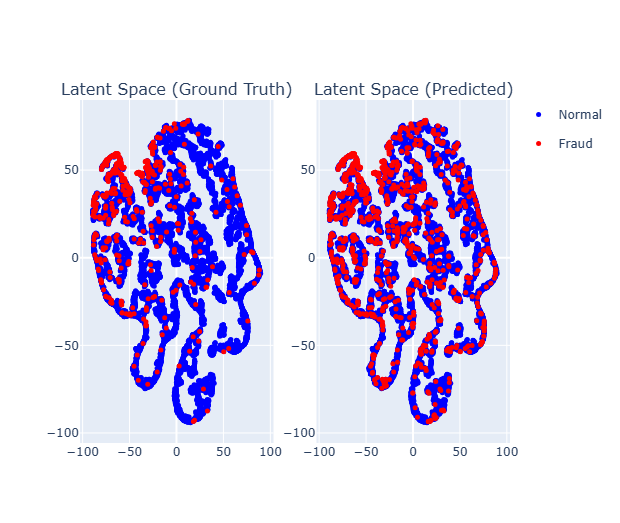

function: plot_latent_space_2d successfully executed at 32.77028179168701s


In [54]:
plot_latent_space_2d(
    embeddings=embeddings,
    y_test=y_all,
    y_pred=y_pred_all,
    index_df=all_df,        # DataFrame to use for hover info
    hover_col='sales_id'     # column in test_df to display on hover
)

function: plot_latent_space_3d is starting...


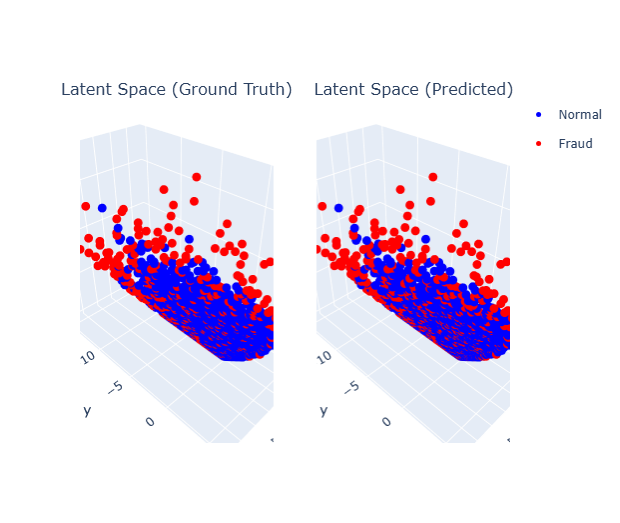

function: plot_latent_space_3d successfully executed at 0.2748229503631592s


In [57]:
plot_latent_space_3d(
    embeddings=embeddings,
    y_test=y_all,
    y_pred=y_pred_all,
    index_df=all_df,        # DataFrame to use for hover info
    hover_col='sales_id'     # column in test_df to display on hover
)

In [61]:
pd.DataFrame({
    "y_all": pd.Series(y_all).value_counts(),
    "y_pred_all": pd.Series(y_pred_all).value_counts()
}).fillna(0).astype(int)

,y_all,y_pred_all
0,9526,9044
1,474,956


## [ALL] Packing

In [62]:
result_all_df = create_pack_results(all_df, y_pred_all, experiment_name='ae_all_1')
result_all_df

function: create_pack_results is starting...
function: create_pack_results successfully executed at 0.0014464855194091797s


,sales_id,ae_all_1
0,3630,0
1,5986,0
2,7036,0
3,628,0
4,6352,0
...,...,...
9995,3178,0
9996,9980,0
9997,1440,1
9998,8684,0


# Pipeline - pending

In [54]:
# design arch
in_x = X_scaled_train.shape[1] # จำนวน features -> input_dim
h1 = X_scaled_train.shape[1]//2 #  -> number of neuron in hidden layer 1
h2 = X_scaled_train.shape[1]//4 # -> hidden 2
h3 = X_scaled_train.shape[1]//8 # -> hidden 3

print(f'input layer dim = {in_x}')
print(f'hidden layer dim #1 = {h1}')
print(f'hidden layer dim #2 = {h2}')
print(f'hidden layer dim #3 = {h3}')

input layer dim = 60
hidden layer dim #1 = 30
hidden layer dim #2 = 15
hidden layer dim #3 = 7


In [29]:
from torchinfo import summary
set_seed(42)

model_ae = Autoencoder(input_dim=in_x, 
                         encoding_dim=3, 
                         hidden_layers=[h1, 
                                        h2,
                                        h3,
                                       ],
                         dropout=0.2,
                         verbose=False
                        )

# This is only used for testing the model architecture, not training or evaluating on real data.
dummy_input = torch.randn(5, X_scaled_train.shape[1]) 
summary(model_ae, input_data=dummy_input, verbose=0)

function: set_seed is starting...
function: set_seed successfully executed at 0.009614229202270508s


Layer (type:depth-idx)                   Output Shape              Param #
Autoencoder                              [5, 60]                   --
├─Sequential: 1-1                        --                        --
│    └─Linear: 2-1                       [5, 30]                   1,830
│    └─ReLU: 2-2                         [5, 30]                   --
│    └─Dropout: 2-3                      [5, 30]                   --
│    └─Linear: 2-4                       [5, 15]                   465
│    └─ReLU: 2-5                         [5, 15]                   --
│    └─Dropout: 2-6                      [5, 15]                   --
│    └─Linear: 2-7                       [5, 7]                    112
│    └─ReLU: 2-8                         [5, 7]                    --
│    └─Dropout: 2-9                      [5, 7]                    --
│    └─Linear: 2-10                      [5, 3]                    24
├─Sequential: 1-2                        --                        --
│    └─Lin

[autoreload of package.model_deep_ae_20250826 failed: Traceback (most recent call last):
  File "C:\Users\alice.var\AppData\Local\miniconda3\envs\ad-env\Lib\site-packages\IPython\extensions\autoreload.py", line 280, in check
    elif self.deduper_reloader.maybe_reload_module(m):
         ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^
  File "C:\Users\alice.var\AppData\Local\miniconda3\envs\ad-env\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 533, in maybe_reload_module
    new_source_code = f.read()
  File "C:\Users\alice.var\AppData\Local\miniconda3\envs\ad-env\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x81 in position 48789: character maps to <undefined>
]


function: run_training_pipeline is starting...
function: set_seed is starting...
function: set_seed successfully executed at 0.00390625s
function: train_autoencoder_checkpoint is starting...
[INFO] Using device: cpu
[INFO] DataLoader seed info:
       Global generator manual_seed: 42
       Torch initial seed: 42
       Generator state (deterministic): True
       Benchmark mode: False
[INFO] Using loss function: L1Loss
[INFO] Using optimizer: Adam, LR: 0.001000
function: get_scheduler is starting...
function: get_scheduler successfully executed at 0.0001354217529296875s
[INFO] Using scheduler: ReduceLROnPlateau with params: {'factor': 0.5, 'patience': 5, 'step_size': 10}
Epoch [1/20] - Train Loss: 0.7994, Val Loss: 0.7953
Epoch [2/20] - Train Loss: 0.7959, Val Loss: 0.7913
Epoch [3/20] - Train Loss: 0.7942, Val Loss: 0.7905
Epoch [4/20] - Train Loss: 0.7933, Val Loss: 0.7905
Epoch [5/20] - Train Loss: 0.7928, Val Loss: 0.7899
Epoch [6/20] - Train Loss: 0.7922, Val Loss: 0.7898
Epoch [

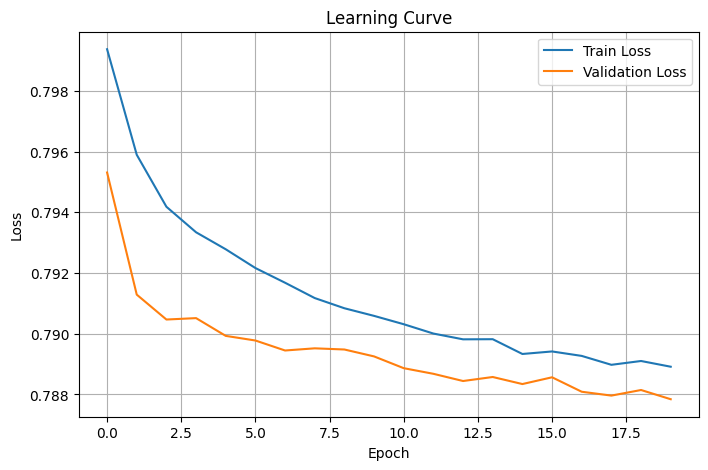

function: plot_learning_curve successfully executed at 0.28481268882751465s
function: create_pack_results is starting...
function: create_pack_results successfully executed at 0.002711057662963867s
function: get_reconstruction_error is starting...
[INFO] Reconstruction error calculated using MAE for 2000 samples
[INFO] Error stats -> min: 0.5405, max: 3.6015, mean: 0.8991
function: get_reconstruction_error successfully executed at 0.010333538055419922s
function: evaluate_thresholds is starting...
function: flag_anomalies is starting...
function: flag_anomalies successfully executed at 8.416175842285156e-05s
function: create_pack_results is starting...
function: create_pack_results successfully executed at 0.00019669532775878906s
function: flag_anomalies is starting...
function: flag_anomalies successfully executed at 3.62396240234375e-05s
function: create_pack_results is starting...
function: create_pack_results successfully executed at 0.00023365020751953125s
function: flag_anomalies 

100%|██████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 91.04it/s]

function: evaluate_fraud_predictions successfully executed at 0.15316557884216309s
function: evaluate_thresholds successfully executed at 0.17589473724365234s
function: run_training_pipeline successfully executed at 11.1209716796875s
function: run_threshold_and_plot_pipeline is starting...
function: get_reconstruction_error is starting...
[INFO] Reconstruction error calculated using MSE for 2000 samples
[INFO] Error stats -> min: 0.4929, max: 15.4354, mean: 1.5171
function: get_reconstruction_error successfully executed at 0.005980730056762695s
Selected threshold (95 percentile): 1.2970
function: flag_anomalies is starting...
function: flag_anomalies successfully executed at 2.2411346435546875e-05s
function: extract_embeddings is starting...
[INFO] Using device: cpu
[INFO] Input shape: torch.Size([2000, 60])
[INFO] Extracted embeddings shape: (2000, 3)
function: extract_embeddings successfully executed at 0.0009796619415283203s
function: plot_latent_space_2d is starting...


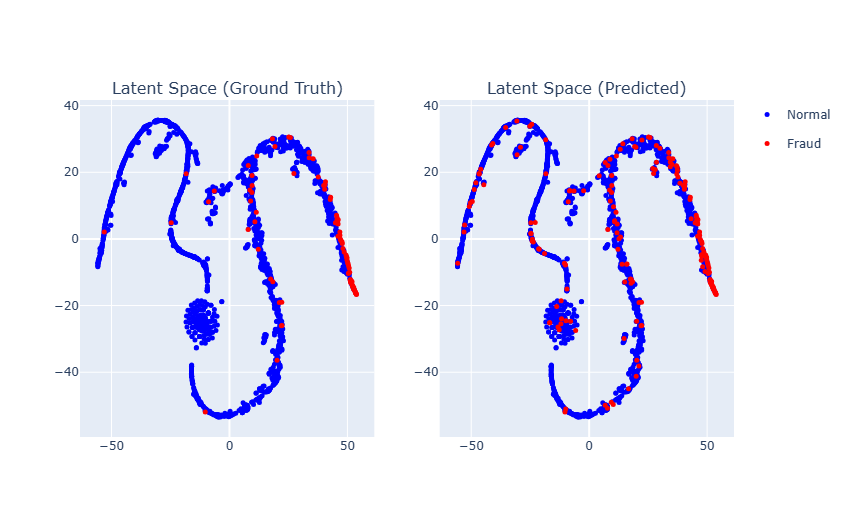

function: plot_latent_space_2d successfully executed at 8.78293228149414s
function: plot_latent_space_3d is starting...


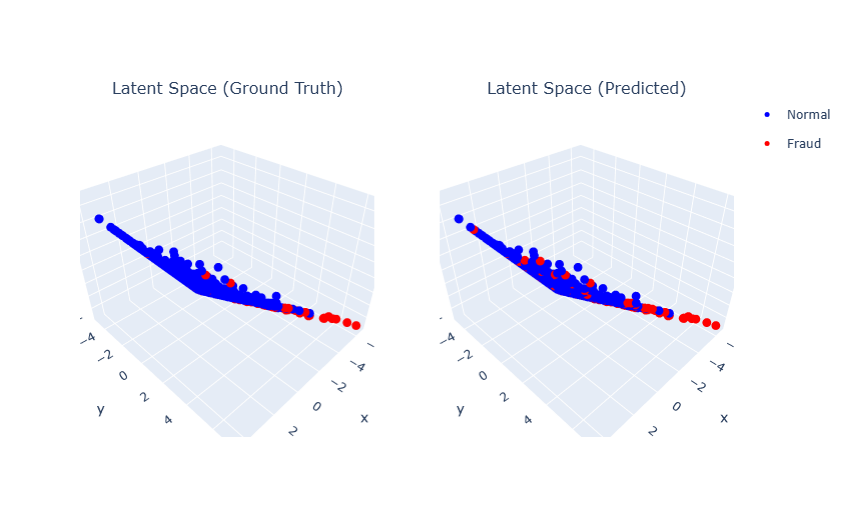

function: plot_latent_space_3d successfully executed at 0.11974334716796875s
function: run_threshold_and_plot_pipeline successfully executed at 8.919070720672607s


In [30]:
# Step 1: Train and evaluate
trained_model, train_losses, val_losses, df_lables, res_thresholds = run_training_pipeline(
    model=model_ae,
    X_scaled_train=X_scaled_train,
    X_scaled_val=X_scaled_val,
    X_scaled_test=X_scaled_test,
    test_df=test_df,
    y_test=y_test,
    true_fraud_list=true_fraud_list,
    seed= 42,
    epochs = 10,
    checkpoint_every= 10,
    early_stopping_patience = 10,
    run_dir= "model_checkpoint",
    loss_name= "mae",
    optimizer_name = "adam"
)

# Step 2: Manual threshold selection & latent space plots
recon_error, threshold, y_pred, embeddings = run_threshold_and_plot_pipeline(
    trained_model=trained_model,
    X_scaled_test=X_scaled_test,
    test_df=test_df,
    y_test=y_test,
    threshold_percentile=95,
    hover_col='sales_id'
)


In [24]:
res_thresholds

,experiments,total_alert,tp,fp,tn,fn,precision,recall,f0.5,f1
0,ae_default_all_p10,1809,95,1714,191,0,0.052515,1.0,0.064793,0.099790
1,ae_default_all_p20,1619,95,1524,381,0,0.058678,1.0,0.072287,0.110852
2,ae_default_all_p30,1428,95,1333,572,0,0.066527,1.0,0.081798,0.124754
3,ae_default_all_p40,1238,95,1143,762,0,0.076737,1.0,0.094115,0.142536
4,ae_default_all_p50,1047,95,952,953,0,0.090735,1.0,0.110904,0.166375
5,ae_default_all_p60,857,95,762,1143,0,0.110852,1.0,0.134828,0.199580
6,ae_default_all_p70,667,95,572,1333,0,0.142429,1.0,0.171915,0.249344
7,ae_default_all_p80,476,95,381,1524,0,0.199580,1.0,0.237619,0.332750
8,ae_default_all_p85,381,95,286,1619,0,0.249344,1.0,0.293391,0.399160
9,ae_default_all_p90,286,95,191,1714,0,0.332168,1.0,0.383374,0.498688


# Laplacian
https://www.numberanalytics.com/blog/laplacian-eigenmaps-dimensionality-reduction

In [35]:
import numpy as np
from scipy.spatial import distance
import plotly.express as px
import pandas as pd

@timer
def plot_laplacian_eigenmaps_3d(X_scaled_test, y_test, test_df, hover_col='sales_id', n_components=3, sigma=1.0, title="3D Laplacian Eigenmaps"):
    """
    Compute 3D Laplacian Eigenmaps and plot with Plotly.
    y_test should be discrete (0/1).
    
    Parameters:
    - X_scaled_test: np.array or pd.DataFrame of test features
    - y_test: np.array or pd.Series of discrete labels (0/1)
    - test_df: pd.DataFrame containing hover column
    - hover_col: column name to show on hover
    - n_components: number of eigenmaps (default 3)
    - sigma: RBF kernel parameter
    """
    # Weight matrix
    W = np.exp(-distance.cdist(X_scaled_test, X_scaled_test, 'sqeuclidean') / (2 * sigma ** 2))
    D = np.diag(np.sum(W, axis=1))
    L = D - W

    # Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eig(L)
    idx = np.argsort(eigenvalues)
    
    # Take only real part
    X_3d = np.real(eigenvectors[:, idx[1:n_components+1]])

    # Prepare DataFrame
    df_plot = pd.DataFrame(X_3d, columns=[f'LE{i+1}' for i in range(n_components)])
    df_plot['y_test'] = y_test.astype(int).astype(str)  # cast to string for discrete colors
    df_plot[hover_col] = test_df[hover_col].values

    # 3D scatter plot with discrete colors and hover
    fig = px.scatter_3d(
        df_plot,
        x='LE1',
        y='LE2',
        z='LE3',
        color='y_test',
        color_discrete_map={'0': 'blue', '1': 'red'},
        hover_data=[hover_col],
        title=title,
        opacity=0.8
    )
    # fig.show()
    return fig

function: plot_laplacian_eigenmaps_3d is starting...
function: plot_laplacian_eigenmaps_3d successfully executed at 5.330060720443726s


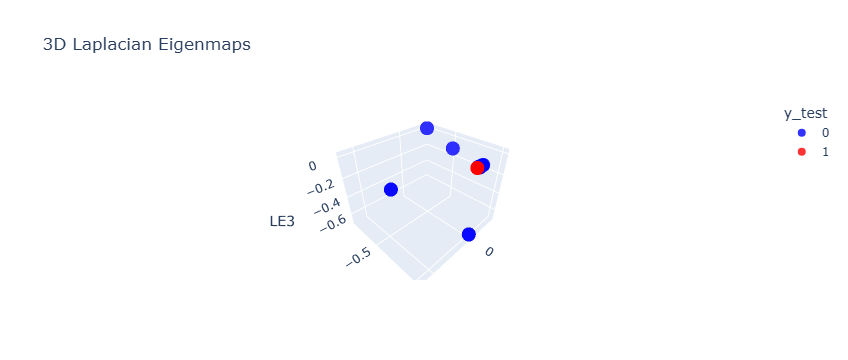

In [36]:
plot_laplacian_eigenmaps_3d(
    X_scaled_test=X_scaled_test,
    y_test=y_test,
    test_df=test_df,
    hover_col='sales_id',
    n_components=3,
    sigma=1.0
)

# [13-08-2025] ตัด label ว่า แล้วตัวที่ predict (แดง) อยู่่ใน่ กลุ่มก้อน 
หา overlap ว่าเกิดเท่าไหร่ 
มิติเล็กลงเห็นไร

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.cluster import DBSCAN
# from sklearn.preprocessing import StandardScaler

# def cluster_embeddings(embeddings, sales_ids=None, labels=None, eps=0.5, min_samples=5):
#     """
#     Cluster 3D embeddings using DBSCAN and visualize results.
    
#     Parameters:
#     - embeddings: np.ndarray (n_samples, 3)
#     - sales_ids: list or array of IDs (optional)
#     - labels: list or array of fraud labels (optional)
#     - eps: DBSCAN eps parameter
#     - min_samples: DBSCAN min_samples parameter
    
#     Returns:
#     - DataFrame with sales_id, cluster_id, and label (if provided)
#     """
    
#     # Standardize embeddings for DBSCAN
#     embeddings_scaled = StandardScaler().fit_transform(embeddings)
    
#     # Run DBSCAN
#     dbscan = DBSCAN(eps=eps, min_samples=min_samples)
#     cluster_ids = dbscan.fit_predict(embeddings_scaled)
    
#     # Prepare results DataFrame
#     df = pd.DataFrame({
#         "sales_id": sales_ids if sales_ids is not None else np.arange(len(embeddings)),
#         "cluster_id": cluster_ids
#     })
    
#     if labels is not None:
#         df["label"] = labels
    
#     # Plot results
#     fig = plt.figure(figsize=(14, 6))
    
#     ax1 = fig.add_subplot(121, projection='3d')
#     scatter1 = ax1.scatter(embeddings[:, 0], embeddings[:, 1], embeddings[:, 2],
#                            c=cluster_ids, cmap='tab10', s=20)
#     ax1.set_title("Clusters (DBSCAN)")
#     plt.colorbar(scatter1, ax=ax1, label="Cluster ID")
    
#     ax2 = fig.add_subplot(122, projection='3d')
#     if labels is not None:
#         scatter2 = ax2.scatter(embeddings[:, 0], embeddings[:, 1], embeddings[:, 2],
#                                c=labels, cmap='coolwarm', s=20)
#         ax2.set_title("Fraud vs Normal")
#         plt.colorbar(scatter2, ax=ax2, label="Label (0=Normal, 1=Fraud)")
#     else:
#         ax2.set_title("No Labels Provided")
    
#     plt.show()
    
#     return df


In [ ]:
# df_clusters = cluster_embeddings(
#     embeddings=embeddings,
#     sales_ids=np.arange(len(embeddings)),
#     labels=np.random.randint(0, 2, size=embeddings.shape[0]),  # Replace with your real labels
#     eps=0.5,
#     min_samples=5
# )
# df_clusters

# [13-08-2025] อยากให้ลองทำทั้ง novelty , anomaly and supervised (เอาคนที่เรา predict จาก novelty/anomaly ไปเป็น label)